# Chapter 18 - The de Rham Theorem

**Source Span.** `Introduction to Smooth Manifolds.pdf`, printed pages `467-489`.

**Chapter Goal.** Explain why integrating smooth differential forms over smooth singular chains gives an isomorphism from de Rham cohomology to singular cohomology with real coefficients.

Chapter 17 showed that de Rham cohomology behaves like a topological invariant. Chapter 18 identifies the topological object it equals. The source chapter first sketches singular homology, then singular cohomology, then smooth singular homology, and finally proves the de Rham theorem by comparing Mayer-Vietoris sequences with the five lemma.

This notebook keeps the chain-level mechanics visible. Singular chains are formal sums of maps from standard simplices. Boundaries alternate signs and satisfy `boundary^2 = 0`. Smooth singular chains are enough because continuous simplices can be smoothed without changing homology. Integration of a `p`-form over a smooth `p`-chain produces a real number, and Stokes's theorem says that integration respects the boundary/coboundary relation. That compatibility is the bridge from calculus to topology.

## Visual Storyboard

| Chapter idea | Representation | Library | Inspection target | Check |
| --- | --- | --- | --- | --- |
| singular chains and faces | oriented standard simplex diagram | NumPy, Matplotlib | alternating boundary signs | `boundary_1 @ boundary_2 = 0` |
| smooth singular homology | smoothing homotopy picture for a kinked simplex | NumPy, Matplotlib | endpoints/faces fixed while interior is smoothed | endpoint equality and shorter curvature spike |
| integration over chains | Stokes on a standard triangle | SymPy, Matplotlib | boundary integral equals integral of exterior derivative | both integrals equal `1/2` |
| de Rham homomorphism | pairing table for circle forms and cycles | NumPy, CSV/JSON | a cohomology class becomes a singular cohomology functional | angular period normalization |
| naturality and Mayer-Vietoris | commutative comparison diagram | NetworkX, Matplotlib | where the integration map must commute | all named squares are present |
| proof of theorem | five-lemma/de Rham-cover induction diagram | NetworkX, Matplotlib | why local isomorphisms imply global isomorphism | exact-row and isomorphism flags |

The chapter is a bridge chapter. The visuals therefore emphasize algebraic wiring and integration checks rather than decorative geometry.

## Setup

Artifacts are saved under `artifacts/chapter-18-the-de-rham-theorem/`. All computations are deliberately small enough to rerun during notebook validation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
if BOOK_ROOT.name != "Introduction-to-Smooth-Manifolds":
    BOOK_ROOT = next(path for path in [BOOK_ROOT, *BOOK_ROOT.parents] if path.name == "Introduction-to-Smooth-Manifolds")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-18-the-de-rham-theorem"
UNIT_TITLE = "The de Rham Theorem"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

artifacts: list[Path] = []
check_paths: list[Path] = []

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def artifact_record(path: Path) -> dict[str, object]:
    return {
        "path": str(path.relative_to(BOOK_ROOT)).replace("\\", "/"),
        "bytes": path.stat().st_size,
    }

print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifact root: artifacts\chapter-18-the-de-rham-theorem


## Library Routing

Matplotlib handles simplex, homotopy, and proof diagrams. NumPy handles boundary matrices and rank checks. SymPy verifies the Stokes calculation exactly. NetworkX is used only for proof wiring, where its graph structure is a better fit than a freehand picture. CSV and JSON artifacts record the invariants that make the notebook auditable.

## 1. Singular Chains: Boundary Signs Matter

A singular `p`-simplex is a continuous map from the standard `p`-simplex into the space. A chain is a finite formal sum of such simplices. The boundary operator is an alternating sum of restrictions to faces. The sign pattern is not cosmetic: it is exactly what makes the boundary of a boundary vanish.

The filled triangle below is the smallest useful model. Its oriented boundary is the sum of three directed edges, and the boundary of those edges cancels at every vertex.

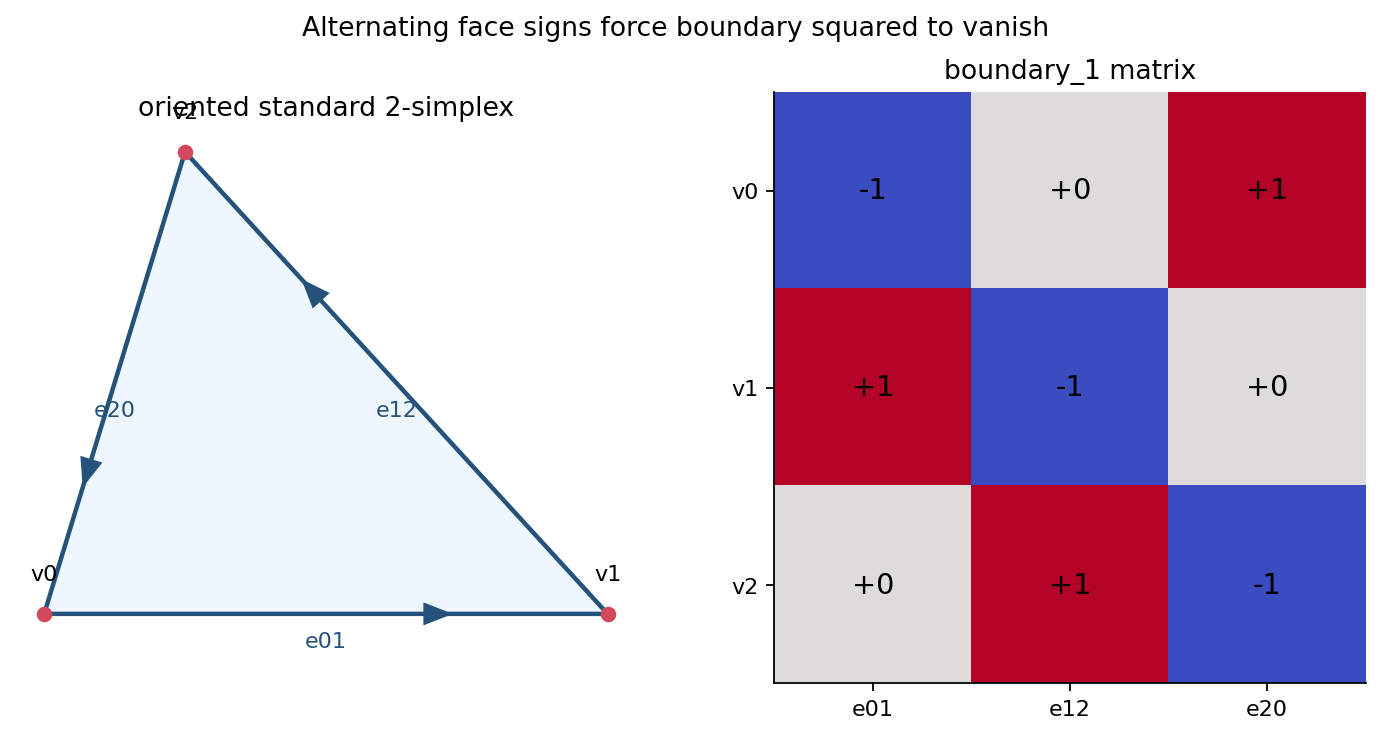

In [2]:
boundary_1 = np.array(
    [
        [-1, 0, 1],
        [1, -1, 0],
        [0, 1, -1],
    ],
    dtype=int,
)
boundary_2 = np.array([[1], [1], [1]], dtype=int)
boundary_squared = boundary_1 @ boundary_2

vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.25, 0.82]])
edges = [(0, 1, "e01"), (1, 2, "e12"), (2, 0, "e20")]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.8))
triangle = plt.Polygon(vertices, closed=True, facecolor="#eef6ff", edgecolor="#24527a", linewidth=2)
ax0.add_patch(triangle)
for i, (xv, yv) in enumerate(vertices):
    ax0.scatter([xv], [yv], color="#d1495b", zorder=5)
    ax0.text(xv, yv + 0.06, f"v{i}", ha="center")
for a, b, label in edges:
    start, end = vertices[a], vertices[b]
    direction = end - start
    ax0.arrow(start[0], start[1], 0.72 * direction[0], 0.72 * direction[1], head_width=0.035, head_length=0.045, color="#24527a", length_includes_head=True)
    mid = 0.5 * (start + end)
    ax0.text(mid[0], mid[1] - 0.06, label, color="#24527a", ha="center")
ax0.set_aspect("equal")
ax0.axis("off")
ax0.set_title("oriented standard 2-simplex")

ax1.imshow(boundary_1, cmap="coolwarm", vmin=-1, vmax=1)
for (i, j), value in np.ndenumerate(boundary_1):
    ax1.text(j, i, f"{value:+d}", ha="center", va="center", fontsize=13)
ax1.set_xticks([0, 1, 2], labels=["e01", "e12", "e20"])
ax1.set_yticks([0, 1, 2], labels=["v0", "v1", "v2"])
ax1.set_title("boundary_1 matrix")
fig.suptitle("Alternating face signs force boundary squared to vanish")
simplex_path = save_matplotlib(fig, FIGURES / "singular-simplex-boundary-signs.png")
plt.close(fig)
artifacts.append(simplex_path)

boundary_rows = [
    {"edge": "e01", "orientation": "v0 to v1", "v0": -1, "v1": 1, "v2": 0, "role": "first boundary edge"},
    {"edge": "e12", "orientation": "v1 to v2", "v0": 0, "v1": -1, "v2": 1, "role": "second boundary edge"},
    {"edge": "e20", "orientation": "v2 to v0", "v0": 1, "v1": 0, "v2": -1, "role": "third boundary edge"},
]
boundary_table = save_csv(boundary_rows, TABLES / "simplex-boundary-matrix.csv")
artifacts.append(boundary_table)
boundary_check = save_json(
    {
        "boundary_1": boundary_1.tolist(),
        "boundary_2": boundary_2.tolist(),
        "boundary_squared": boundary_squared.tolist(),
        "boundary_squared_zero": bool(np.all(boundary_squared == 0)),
    },
    CHECKS / "singular-simplex-boundary-signs.json",
)
check_paths.append(boundary_check)
display_artifact(simplex_path, width=900)

## 2. Smooth Singular Chains Are Enough

The de Rham pairing needs smooth simplices because forms are pulled back by differentiable maps. The source chapter proves that including smooth singular chains into all singular chains induces the same homology. The technical proof builds a smoothing operator and a chain homotopy.

The picture below is a one-dimensional cartoon of that proof: a continuous/kinked simplex is replaced by a smooth simplex with the same endpoints. The important invariant is not that the curves look close; it is that the boundary faces are respected, so the homology class is unchanged after adding a chain homotopy.

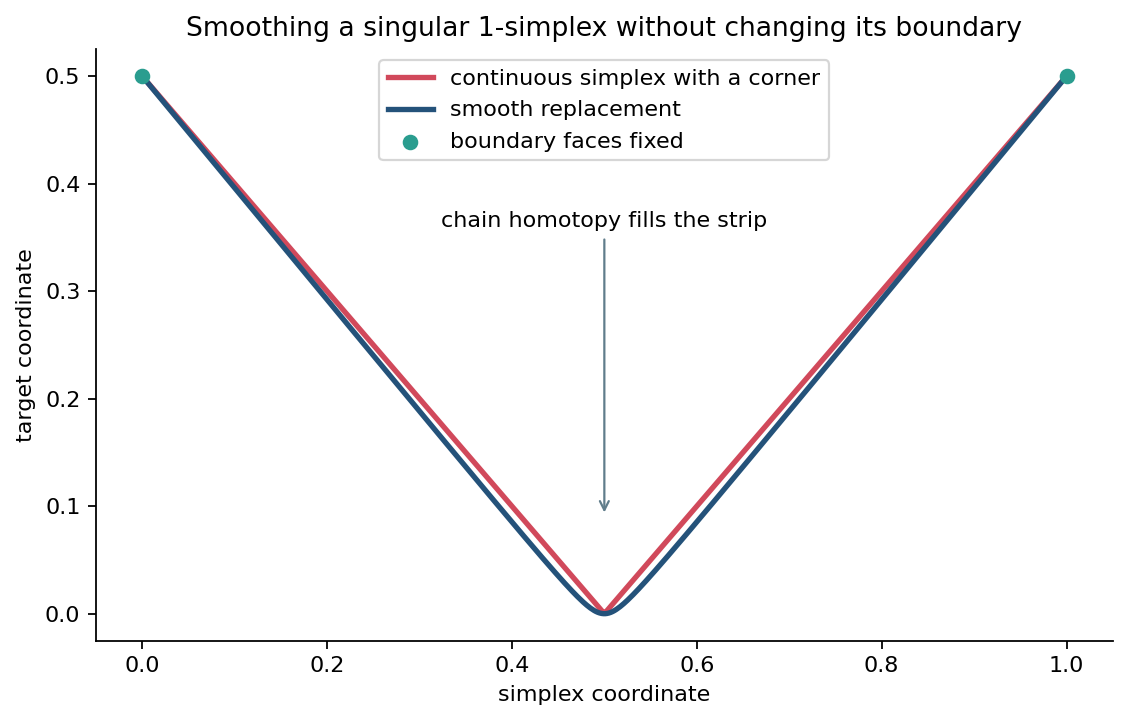

In [3]:
s = np.linspace(0, 1, 500)
kink = np.abs(s - 0.5)
smooth = np.sqrt((s - 0.5) ** 2 + 0.02**2) - 0.02
smooth *= kink.max() / smooth.max()
endpoint_match = bool(np.allclose([kink[0], kink[-1]], [smooth[0], smooth[-1]], atol=1e-12))
kink_second_jump = float(np.max(np.abs(np.diff(np.diff(kink)))))
smooth_second_jump = float(np.max(np.abs(np.diff(np.diff(smooth)))))

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(s, kink, color="#d1495b", lw=2.4, label="continuous simplex with a corner")
ax.plot(s, smooth, color="#24527a", lw=2.4, label="smooth replacement")
ax.scatter([0, 1], [0.5, 0.5], color="#2a9d8f", zorder=5, label="boundary faces fixed")
ax.annotate("chain homotopy fills the strip", xy=(0.5, 0.09), xytext=(0.5, 0.36), ha="center", arrowprops={"arrowstyle": "->", "color": "#607d8b"})
ax.set_xlabel("simplex coordinate")
ax.set_ylabel("target coordinate")
ax.set_title("Smoothing a singular 1-simplex without changing its boundary")
ax.legend(loc="upper center")
smoothing_path = save_matplotlib(fig, FIGURES / "smooth-singular-homology-smoothing-homotopy.png")
plt.close(fig)
artifacts.append(smoothing_path)

smoothing_check = save_json(
    {
        "endpoint_match": endpoint_match,
        "kink_second_difference_max": kink_second_jump,
        "smooth_second_difference_max": smooth_second_jump,
        "smooth_replacement_reduces_corner_spike": bool(smooth_second_jump < kink_second_jump),
    },
    CHECKS / "smooth-singular-homology-smoothing-homotopy.json",
)
check_paths.append(smoothing_check)
display_artifact(smoothing_path, width=820)

## 3. Stokes For Chains: The Integration Map Is A Cochain Map

The de Rham homomorphism sends a cohomology class of closed `p`-forms to a singular cohomology class by evaluating the form on smooth `p`-cycles. Stokes's theorem is the compatibility check:

`integral over boundary(c) of eta = integral over c of d eta`.

On the standard triangle, take `eta = x dy`. Then `d eta = dx wedge dy`, so the integral over the triangle is its area. The oriented boundary integral gives the same number.

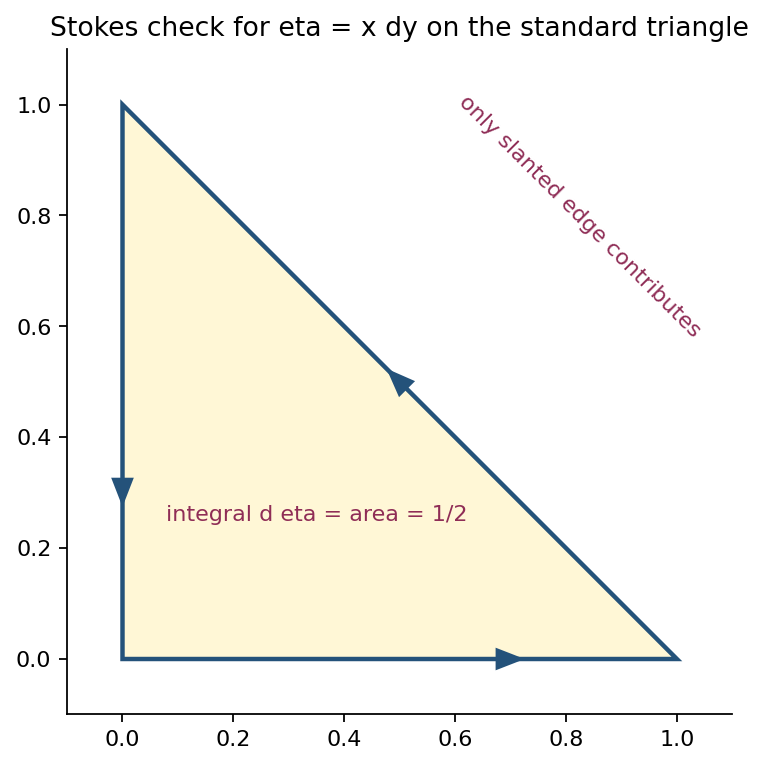

In [4]:
u, v = sp.symbols("u v", real=True)
area_integral = sp.integrate(1, (v, 0, 1 - u), (u, 0, 1))
# Edge e01 has y=0, so x dy = 0. Edge e12: x=1-t, y=t. Edge e20: x=0.
tau = sp.symbols("tau", real=True)
edge_e01 = sp.Integer(0)
edge_e12 = sp.integrate(1 - tau, (tau, 0, 1))
edge_e20 = sp.Integer(0)
boundary_integral = sp.simplify(edge_e01 + edge_e12 + edge_e20)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
tri = plt.Polygon([[0, 0], [1, 0], [0, 1]], closed=True, facecolor="#fff7d6", edgecolor="#24527a", linewidth=2)
ax.add_patch(tri)
ax.arrow(0, 0, 0.72, 0, head_width=0.035, head_length=0.045, color="#24527a", length_includes_head=True)
ax.arrow(1, 0, -0.52, 0.52, head_width=0.035, head_length=0.045, color="#24527a", length_includes_head=True)
ax.arrow(0, 1, 0, -0.72, head_width=0.035, head_length=0.045, color="#24527a", length_includes_head=True)
ax.text(0.35, 0.25, "integral d eta = area = 1/2", ha="center", color="#8f2d56")
ax.text(0.6, 0.58, "only slanted edge contributes", rotation=-45, color="#8f2d56")
ax.set_aspect("equal")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_title("Stokes check for eta = x dy on the standard triangle")
stokes_path = save_matplotlib(fig, FIGURES / "stokes-chain-standard-triangle.png")
plt.close(fig)
artifacts.append(stokes_path)

stokes_check = save_json(
    {
        "area_integral": str(area_integral),
        "boundary_integral": str(boundary_integral),
        "edge_e01": str(edge_e01),
        "edge_e12": str(edge_e12),
        "edge_e20": str(edge_e20),
        "stokes_identity_holds": bool(sp.simplify(area_integral - boundary_integral) == 0),
    },
    CHECKS / "stokes-chain-standard-triangle.json",
)
check_paths.append(stokes_check)
display_artifact(stokes_path, width=680)

## 4. The de Rham Homomorphism As A Pairing

The singular cohomology group with real coefficients can be viewed as functionals on homology. The de Rham homomorphism takes a closed form and turns it into such a functional by integration over smooth cycles.

On `S^1`, the normalized angular form `(1/2pi) d theta` evaluates to `1` on the positively oriented fundamental cycle, to `-1` on the reversed cycle, and to `0` on a constant cycle. This is the concrete behavior the theorem generalizes to every smooth manifold and every degree.

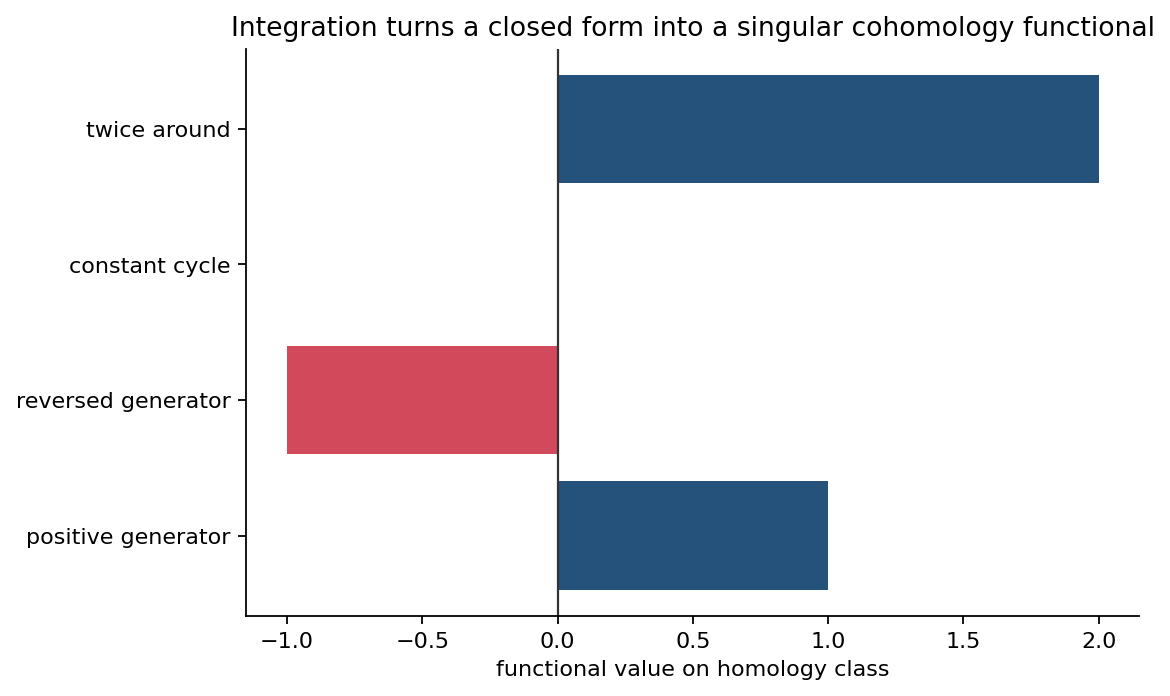

In [5]:
cycle_rows = [
    {"cycle": "positive generator", "winding_number": 1, "integral_normalized_dtheta": 1.0},
    {"cycle": "reversed generator", "winding_number": -1, "integral_normalized_dtheta": -1.0},
    {"cycle": "constant cycle", "winding_number": 0, "integral_normalized_dtheta": 0.0},
    {"cycle": "twice around", "winding_number": 2, "integral_normalized_dtheta": 2.0},
]
pairing_table = save_csv(cycle_rows, TABLES / "de-rham-homomorphism-circle-pairing.csv")
artifacts.append(pairing_table)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
labels = [row["cycle"] for row in cycle_rows]
values = [row["integral_normalized_dtheta"] for row in cycle_rows]
colors = ["#24527a" if value >= 0 else "#d1495b" for value in values]
ax.barh(labels, values, color=colors)
ax.axvline(0, color="#333333", lw=1)
ax.set_xlabel("functional value on homology class")
ax.set_title("Integration turns a closed form into a singular cohomology functional")
pairing_path = save_matplotlib(fig, FIGURES / "de-rham-homomorphism-circle-pairing.png")
plt.close(fig)
artifacts.append(pairing_path)

pairing_check = save_json(
    {
        "rows": cycle_rows,
        "normalization": "integral of (1/2pi)dtheta over positive generator is 1",
        "linear_on_winding_numbers": all(row["winding_number"] == row["integral_normalized_dtheta"] for row in cycle_rows),
    },
    CHECKS / "de-rham-homomorphism-circle-pairing.json",
)
check_paths.append(pairing_check)
display_artifact(pairing_path, width=760)

## 5. Naturality And Mayer-Vietoris Compatibility

The proof needs more than a single pairing. The integration map must commute with maps induced by smooth maps and with the connecting maps in Mayer-Vietoris. That compatibility lets the de Rham and singular cohomology long exact sequences sit in one commutative diagram.

The graph records the wiring. Every square is an instruction: if the neighboring pieces are already known isomorphisms, the five lemma can force the middle piece to be an isomorphism.

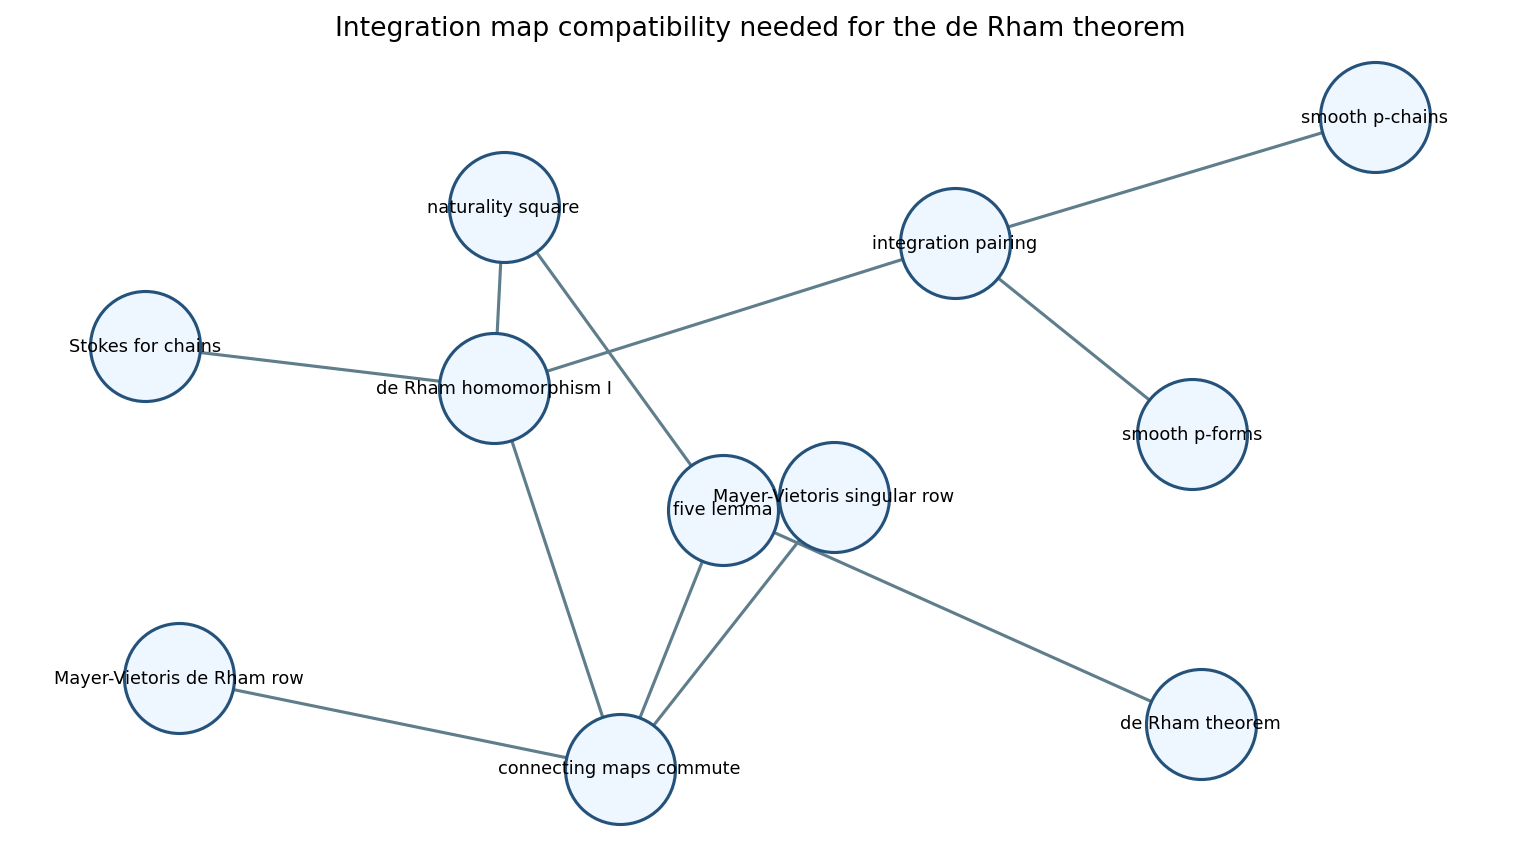

In [6]:
proof_nodes = [
    "smooth p-forms",
    "smooth p-chains",
    "integration pairing",
    "Stokes for chains",
    "de Rham homomorphism I",
    "naturality square",
    "Mayer-Vietoris de Rham row",
    "Mayer-Vietoris singular row",
    "connecting maps commute",
    "five lemma",
    "de Rham theorem",
]
proof_edges = [
    ("smooth p-forms", "integration pairing"),
    ("smooth p-chains", "integration pairing"),
    ("integration pairing", "de Rham homomorphism I"),
    ("Stokes for chains", "de Rham homomorphism I"),
    ("de Rham homomorphism I", "naturality square"),
    ("de Rham homomorphism I", "connecting maps commute"),
    ("Mayer-Vietoris de Rham row", "connecting maps commute"),
    ("Mayer-Vietoris singular row", "connecting maps commute"),
    ("connecting maps commute", "five lemma"),
    ("naturality square", "five lemma"),
    ("five lemma", "de Rham theorem"),
]
proof_graph = nx.DiGraph()
proof_graph.add_edges_from(proof_edges)
proof_graph.add_nodes_from(proof_nodes)
pos = nx.spring_layout(proof_graph, seed=18, k=0.92)
fig, ax = plt.subplots(figsize=(12, 6.4))
nx.draw_networkx_edges(proof_graph, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#607d8b", width=1.4)
nx.draw_networkx_nodes(proof_graph, pos, ax=ax, node_size=2450, node_color="#eef6ff", edgecolors="#24527a", linewidths=1.4)
nx.draw_networkx_labels(proof_graph, pos, ax=ax, font_size=8)
ax.set_title("Integration map compatibility needed for the de Rham theorem")
ax.axis("off")
compatibility_path = save_matplotlib(fig, FIGURES / "de-rham-theorem-compatibility-graph.png")
plt.close(fig)
artifacts.append(compatibility_path)

compatibility_check = save_json(
    {
        "nodes": proof_nodes,
        "edges": proof_edges,
        "required_squares": ["naturality square", "connecting maps commute"],
        "has_required_squares": all(node in proof_nodes for node in ["naturality square", "connecting maps commute"]),
        "acyclic": nx.is_directed_acyclic_graph(proof_graph),
    },
    CHECKS / "de-rham-theorem-compatibility-graph.json",
)
check_paths.append(compatibility_check)
display_artifact(compatibility_path, width=960)

## 6. Five Lemma And The Cover Induction

The final proof strategy is local-to-global. Convex open subsets of Euclidean space are de Rham because their higher de Rham and singular cohomology groups vanish, and degree zero is one-dimensional. A finite de Rham cover is handled by Mayer-Vietoris and the five lemma. A countable locally finite construction then builds the general manifold from such pieces.

The small table below is not a substitute for the proof, but it keeps the induction stages and their hypotheses aligned.

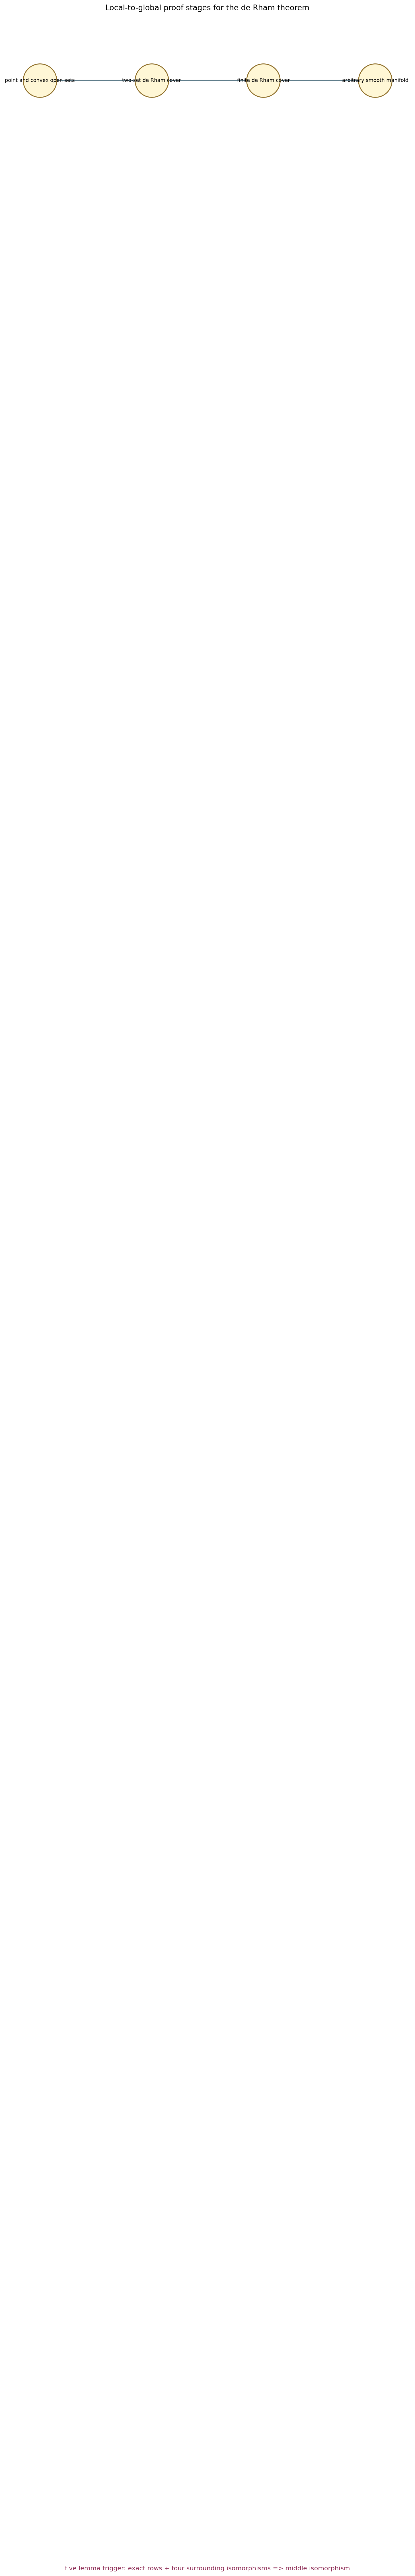

Cover-stage table written to `artifacts\chapter-18-the-de-rham-theorem\tables\de-rham-cover-proof-stages.csv`.

In [7]:
five_lemma_flags = {
    "rows_exact": True,
    "left_two_vertical_maps_iso": True,
    "right_two_vertical_maps_iso": True,
    "middle_forced_iso": True,
}
cover_rows = [
    {"step": "point and convex open sets", "reason": "contractible local model", "tool": "Poincare lemma plus singular homology of a point"},
    {"step": "two-set de Rham cover", "reason": "compare long exact sequences", "tool": "Mayer-Vietoris plus five lemma"},
    {"step": "finite de Rham cover", "reason": "induct by splitting off one set", "tool": "two-set step repeated"},
    {"step": "arbitrary smooth manifold", "reason": "countable basis arranged in separated layers", "tool": "finite-cover result plus disjoint union behavior"},
]
cover_table = save_csv(cover_rows, TABLES / "de-rham-cover-proof-stages.csv")
artifacts.append(cover_table)

G = nx.DiGraph()
for row in cover_rows:
    G.add_node(row["step"])
G.add_edges_from([(cover_rows[i]["step"], cover_rows[i + 1]["step"]) for i in range(len(cover_rows) - 1)])
pos = {row["step"]: (i, 0) for i, row in enumerate(cover_rows)}
fig, ax = plt.subplots(figsize=(11.5, 3.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.8, edge_color="#607d8b")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2800, node_color="#fff7d6", edgecolors="#8f6f2a", linewidths=1.4)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.text(1.5, -0.45, "five lemma trigger: exact rows + four surrounding isomorphisms => middle isomorphism", ha="center", color="#8f2d56")
ax.set_title("Local-to-global proof stages for the de Rham theorem")
ax.axis("off")
cover_path = save_matplotlib(fig, FIGURES / "five-lemma-de-rham-cover-induction.png")
plt.close(fig)
artifacts.append(cover_path)

cover_check = save_json(
    {
        "five_lemma_flags": five_lemma_flags,
        "cover_rows": cover_rows,
        "proof_stage_count": len(cover_rows),
        "five_lemma_conditions_met": all(five_lemma_flags.values()),
    },
    CHECKS / "five-lemma-de-rham-cover-induction.json",
)
check_paths.append(cover_check)
display_artifact(cover_path, width=940)
display(Markdown(f"Cover-stage table written to `{cover_table.relative_to(BOOK_ROOT)}`."))

## Applied Lab

A good way to test the theorem's architecture is to break one compatibility at a time.

- Reverse one face sign in the simplex boundary matrix. The product `boundary_1 @ boundary_2` stops being zero, so homology is not defined.
- Use a non-smooth simplex without smoothing it. The pullback of a differential form is no longer justified at the singular point.
- Replace `eta = x dy` by an exact 1-form on the triangle boundary. Stokes then predicts a zero integral around the closed boundary.
- Remove the commutativity of the Mayer-Vietoris connecting square. The five-lemma comparison no longer has a valid middle map to force.

The de Rham theorem is powerful because each of these small checks is stable in the actual smooth theory.

## Final Sanity Checks

The final cell checks that the notebook covered the source chapter's main concepts and that the generated artifacts carry executable invariants.

In [8]:
coverage_terms = [
    "singular homology",
    "singular cohomology",
    "smooth singular homology",
    "standard simplex",
    "boundary operator",
    "Stokes for chains",
    "de Rham homomorphism",
    "Mayer-Vietoris",
    "five lemma",
    "de Rham theorem",
]

assert np.all(boundary_squared == 0)
assert endpoint_match
assert smooth_second_jump < kink_second_jump
assert sp.simplify(area_integral - boundary_integral) == 0
assert all(row["winding_number"] == row["integral_normalized_dtheta"] for row in cycle_rows)
assert compatibility_check.exists()
assert all(five_lemma_flags.values())
assert_artifacts(artifacts + check_paths, min_bytes=64)

final_sanity = {
    "unit": UNIT_TITLE,
    "source_span": "printed pages 467-489",
    "coverage_terms": coverage_terms,
    "artifact_count": len(artifacts),
    "check_count": len(check_paths),
    "core_invariants": {
        "boundary_squared_zero": bool(np.all(boundary_squared == 0)),
        "smoothing_keeps_boundary": endpoint_match,
        "stokes_triangle_identity": bool(sp.simplify(area_integral - boundary_integral) == 0),
        "circle_pairing_linear": all(row["winding_number"] == row["integral_normalized_dtheta"] for row in cycle_rows),
        "five_lemma_conditions_met": all(five_lemma_flags.values()),
    },
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
display(Markdown(f"Final sanity written to `{final_sanity_path.relative_to(BOOK_ROOT)}`."))
print("final_sanity passed for Chapter 18")

Final sanity written to `artifacts\chapter-18-the-de-rham-theorem\checks\final_sanity.json`.

final_sanity passed for Chapter 18


## Takeaways

Singular homology supplies topological cycles; singular cohomology supplies real-valued functionals on those cycles. Smooth singular chains are enough for smooth manifolds, so differential forms can be integrated over representatives. Stokes's theorem makes integration compatible with the chain and cochain complexes, which means a closed form defines a singular cohomology class and exact forms define the zero class. The de Rham theorem says this construction loses no information and adds no extra information: every real singular cohomology class is represented uniquely by a de Rham class. Mayer-Vietoris and the five lemma are the proof machinery that turns the local calculation on contractible coordinate pieces into the global theorem.